# Установка PySpark

In [ ]:
!pip install pyspark

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("BrooklynSales") \
    .getOrCreate()

print("Spark успешно запущен!")

Spark успешно запущен!


# Подключение и загрузка Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/brooklyn_sales_map.csv"
df = spark.read.csv(path, header=True, inferSchema=True)

df.printSchema()

Mounted at /content/drive
root
 |-- _c0: integer (nullable = true)
 |-- borough1: integer (nullable = true)
 |-- neighborhood: string (nullable = true)
 |-- building_class_category: string (nullable = true)
 |-- tax_class: string (nullable = true)
 |-- block: integer (nullable = true)
 |-- lot: integer (nullable = true)
 |-- easement: string (nullable = true)
 |-- building_class: string (nullable = true)
 |-- address9: string (nullable = true)
 |-- apartment_number: string (nullable = true)
 |-- zip_code: integer (nullable = true)
 |-- residential_units: integer (nullable = true)
 |-- commercial_units: integer (nullable = true)
 |-- total_units: integer (nullable = true)
 |-- land_sqft: double (nullable = true)
 |-- gross_sqft: double (nullable = true)
 |-- year_built: integer (nullable = true)
 |-- tax_class_at_sale: integer (nullable = true)
 |-- building_class_at_sale: string (nullable = true)
 |-- sale_price: double (nullable = true)
 |-- sale_date: date (nullable = true)
 |-- year

# Предобработка

In [ ]:
from pyspark.sql.functions import col, when
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sample_df = df.select("sale_price", "gross_sqft", "year_built").sample(0.1).toPandas()

# Заменяем возможные нули на NaN для корректности графиков
import numpy as np
sample_df.replace(0, np.nan, inplace=True)

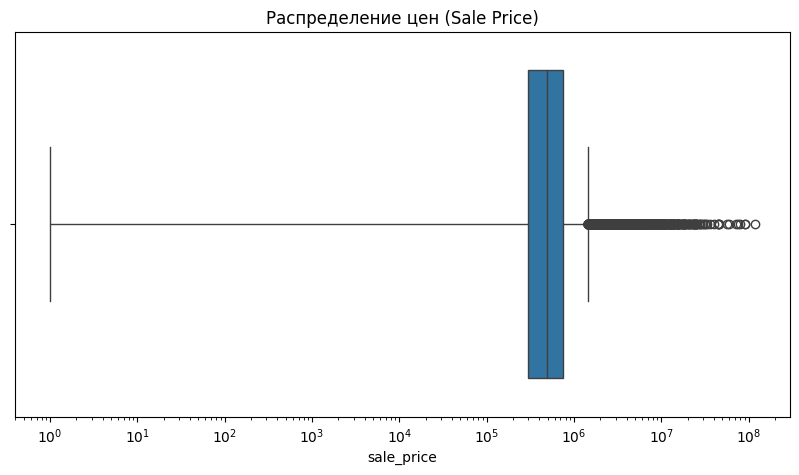

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=sample_df["sale_price"])
plt.title("Распределение цен (Sale Price)")
plt.xscale('log')
plt.show()

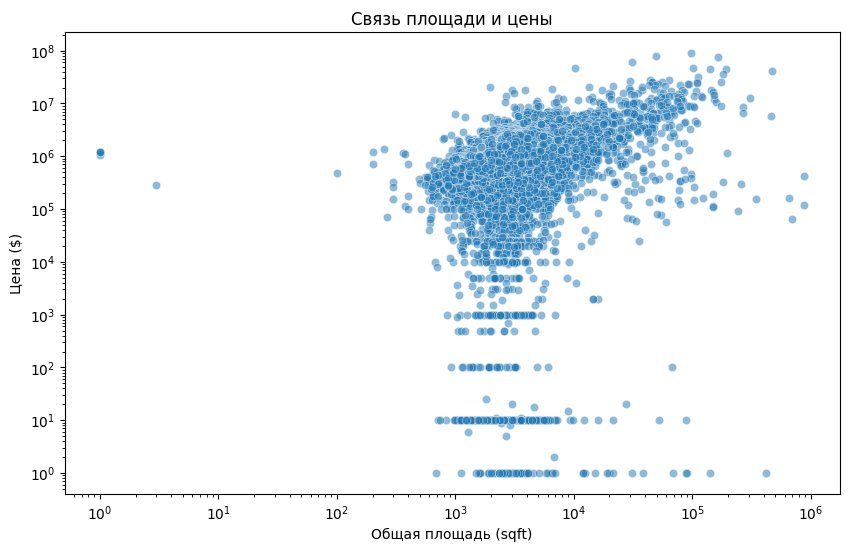

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=sample_df, x="gross_sqft", y="sale_price", alpha=0.5)
plt.yscale('log')
plt.xscale('log')
plt.title("Связь площади и цены")
plt.xlabel("Общая площадь (sqft)")
plt.ylabel("Цена ($)")
plt.show()

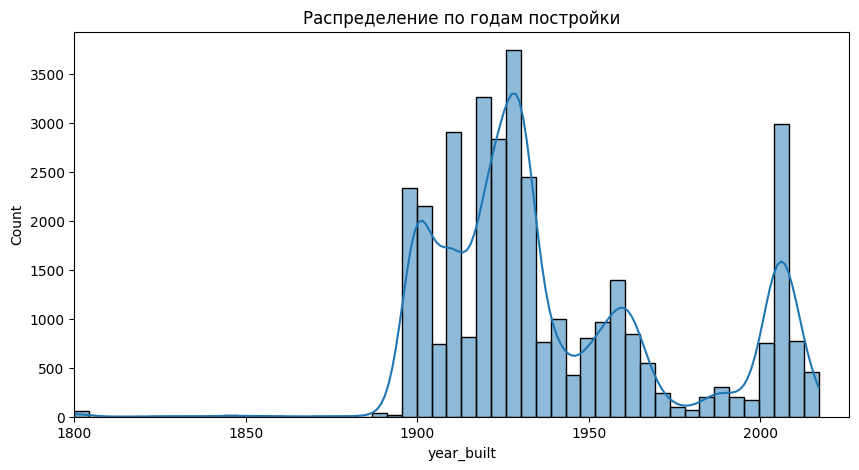

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(sample_df["year_built"].dropna(), bins=50, kde=True)
plt.title("Распределение по годам постройки")
plt.xlim(1800, 2026) # Ограничим, чтобы увидеть реальную картину
plt.show()

In [ ]:
from pyspark.sql.functions import col


df_final_clean = df.filter(
    (col("sale_price") >= 150000) & (col("sale_price") <= 20000000) & # Убираем сверхдешевые и сверхдорогие (выбросы)
    (col("gross_sqft") > 200) & (col("gross_sqft") < 50000) &        # Убираем "шкафы" и мега-заводы
    (col("year_built") > 1890)                                       # Убираем записи с 0 годом
)

print(f"Осталось строк после чистки: {df_final_clean.count()}")

Осталось строк после чистки: 138403


In [ ]:
df_final_clean.printSchema()

root
 |-- _c0: integer (nullable = true)
 |-- borough1: integer (nullable = true)
 |-- neighborhood: string (nullable = true)
 |-- building_class_category: string (nullable = true)
 |-- tax_class: string (nullable = true)
 |-- block: integer (nullable = true)
 |-- lot: integer (nullable = true)
 |-- easement: string (nullable = true)
 |-- building_class: string (nullable = true)
 |-- address9: string (nullable = true)
 |-- apartment_number: string (nullable = true)
 |-- zip_code: integer (nullable = true)
 |-- residential_units: integer (nullable = true)
 |-- commercial_units: integer (nullable = true)
 |-- total_units: integer (nullable = true)
 |-- land_sqft: double (nullable = true)
 |-- gross_sqft: double (nullable = true)
 |-- year_built: integer (nullable = true)
 |-- tax_class_at_sale: integer (nullable = true)
 |-- building_class_at_sale: string (nullable = true)
 |-- sale_price: double (nullable = true)
 |-- sale_date: date (nullable = true)
 |-- year_of_sale: integer (nullabl

# Обучение модели

In [ ]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.sql.functions import when

# Подготовка Label (делим очищенные данные по медиане)
median_val = df_final_clean.stat.approxQuantile("sale_price", [0.5], 0.01)[0]
data_labeled = df_final_clean.withColumn("label", when(col("sale_price") > median_val, 1).otherwise(0))

# Выбор признаков
input_cols = ['gross_sqft', 'year_built', 'tax_class_at_sale', 'total_units']

# Создание вектора признаков
assembler = VectorAssembler(inputCols=input_cols, outputCol="features_raw")
assembled_data = assembler.transform(data_labeled)

# Масштабирование
scaler = StandardScaler(inputCol="features_raw", outputCol="features", withStd=True, withMean=True)
scaled_data = scaler.fit(assembled_data).transform(assembled_data)

# Разделение на обучение и тест (80/20)
train, test = scaled_data.randomSplit([0.8, 0.2], seed=42)

# Обучение модели
lr = LogisticRegression(labelCol="label", featuresCol="features")
lr_model = lr.fit(train)

# Получение прогноза и оценка точности
predictions = lr_model.transform(test)
accuracy = predictions.filter(predictions.label == predictions.prediction).count() / predictions.count()

print(f"--- Результаты ---")
print(f"Медианная цена (порог): {median_val:,.0f} $")
print(f"Итоговая точность (Accuracy): {accuracy:.2%}")

--- Результаты ---
Медианная цена (порог): 570,000 $
Итоговая точность (Accuracy): 61.52%


In [ ]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# regParam — помогает избежать переобучения
# maxIter — даем модели больше времени
lr = LogisticRegression(
    labelCol="label",
    featuresCol="features",
    maxIter=50,
    regParam=0.01,
    elasticNetParam=0.8
)


lr_model = lr.fit(train)


predictions = lr_model.transform(test)

# Считаем точность
accuracy = predictions.filter(predictions.label == predictions.prediction).count() / predictions.count()

# Считаем AUC (дополнительная метрика качества)
evaluator = BinaryClassificationEvaluator(labelCol="label")
auc = evaluator.evaluate(predictions)

print(f"Новая точность (Accuracy): {accuracy:.2%}")
print(f"Качество модели (AUC): {auc:.4f}")

Новая точность (Accuracy): 60.98%
Качество модели (AUC): 0.6806


In [ ]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml import Pipeline

# Индексируем текстовые колонки (Район и Категория здания)
neighborhood_indexer = StringIndexer(inputCol="neighborhood", outputCol="neighborhood_index", handleInvalid="keep")
building_indexer = StringIndexer(inputCol="building_class_category", outputCol="building_index", handleInvalid="keep")

# Собираем расширенный список признаков
extended_input_cols = [
    'gross_sqft',
    'year_built',
    'tax_class_at_sale',
    'total_units',
    'neighborhood_index',
    'building_index'
]


assembler = VectorAssembler(inputCols=extended_input_cols, outputCol="features_raw")


scaler = StandardScaler(inputCol="features_raw", outputCol="features", withStd=True, withMean=True)

# Модель (убираем сильную регуляризацию, даем ей учиться на новых признаках)
lr = LogisticRegression(labelCol="label", featuresCol="features", maxIter=100)

# Упаковываем всё в Pipeline, чтобы не запутаться
pipeline = Pipeline(stages=[neighborhood_indexer, building_indexer, assembler, scaler, lr])

# Обучаем заново на исходных очищенных данных (df_final_clean)
# Сначала добавим label к исходным данным
median_val = df_final_clean.stat.approxQuantile("sale_price", [0.5], 0.01)[0]
data_with_label = df_final_clean.withColumn("label", when(col("sale_price") > median_val, 1).otherwise(0))

train_data, test_data = data_with_label.randomSplit([0.8, 0.2], seed=42)


pipeline_model = pipeline.fit(train_data)
predictions = pipeline_model.transform(test_data)


accuracy = predictions.filter(predictions.label == predictions.prediction).count() / predictions.count()
print(f"Итоговая точность после добавления районов: {accuracy:.2%}")

Итоговая точность после добавления районов: 64.31%


In [ ]:
from pyspark.ml.feature import OneHotEncoder

# Добавляем OneHotEncoder в цепочку
neighborhood_ohe = OneHotEncoder(inputCol="neighborhood_index", outputCol="neighborhood_vec")
building_ohe = OneHotEncoder(inputCol="building_index", outputCol="building_vec")


final_input_cols = [
    'gross_sqft',
    'year_built',
    'tax_class_at_sale',
    'total_units',
    'neighborhood_vec',
    'building_vec'
]


assembler = VectorAssembler(inputCols=final_input_cols, outputCol="features_raw")

scaler = StandardScaler(inputCol="features_raw", outputCol="features", withStd=True, withMean=True)
lr = LogisticRegression(labelCol="label", featuresCol="features", maxIter=100)


pipeline_final = Pipeline(stages=[
    neighborhood_indexer,
    building_indexer,
    neighborhood_ohe,
    building_ohe,
    assembler,
    scaler,
    lr
])


final_model = pipeline_final.fit(train_data)
final_predictions = final_model.transform(test_data)


accuracy = final_predictions.filter(final_predictions.label == final_predictions.prediction).count() / final_predictions.count()
print(f"ФИНАЛЬНАЯ ТОЧНОСТЬ: {accuracy:.2%}")

ФИНАЛЬНАЯ ТОЧНОСТЬ: 73.65%


In [ ]:
for i, col_name in enumerate(final_input_cols[:4]):
    print(f"Признак {col_name}: {lr_model.coefficients[i]:.4f}")

Признак gross_sqft: 0.9796
Признак year_built: -0.0813
Признак tax_class_at_sale: 0.0472
Признак total_units: 0.0000


# Для Yandex Datalens

In [ ]:
import pandas as pd

weights_data = {
    "feature_name": ["gross_sqft", "year_built", "tax_class_at_sale", "total_units"],
    "weight": [0.9796, -0.0813, 0.0472, 0.0000]
}
df_weights = pd.DataFrame(weights_data)

df_weights.to_csv('/content/drive/My Drive/brooklyn_weights.csv', index=False)
print("Файл с весами успешно сохранен на Google Drive!")

Файл с весами успешно сохранен на Google Drive!


In [ ]:
from pyspark.sql.functions import udf
from pyspark.sql.types import DoubleType


get_prob_obj = udf(lambda v: float(v[1]), DoubleType())


df_to_datalens = final_predictions.withColumn("success_probability", get_prob_obj("probability")) \
    .select(
        "neighborhood",
        "building_class_category",
        "year_built",
        "gross_sqft",
        "sale_price",
        "year_of_sale",
        "label",
        "prediction",
        "success_probability"
    )

df_sales_pandas = df_to_datalens.toPandas()


df_sales_pandas.to_csv('/content/drive/My Drive/brooklyn_predictions.csv', index=False)
print("Основной файл с прогнозами успешно сохранен на Google Drive!")

Основной файл с прогнозами успешно сохранен на Google Drive!
